# Generate Report Figures

This notebook re-runs the FD001 RUL prediction pipeline and saves all figures as high-resolution PNGs for the LaTeX report.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_DIR = '../results/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1. Load Data

In [2]:
columns = ['unit', 'cycle',
           'setting_1', 'setting_2', 'setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv('../CMaps/train_FD001.txt',
                        sep='\\s+', header=None, names=columns)

print(f'Shape: {train_df.shape}')
print(f'Number of engines: {train_df["unit"].nunique()}')

Shape: (20631, 26)
Number of engines: 100


## 2. Construct RUL Labels

In [3]:
max_cycles = train_df.groupby('unit')['cycle'].max()
train_df['RUL'] = train_df.apply(
    lambda row: max_cycles[row['unit']] - row['cycle'], axis=1
)

## 3. Figure: Engine Lifetime Distribution

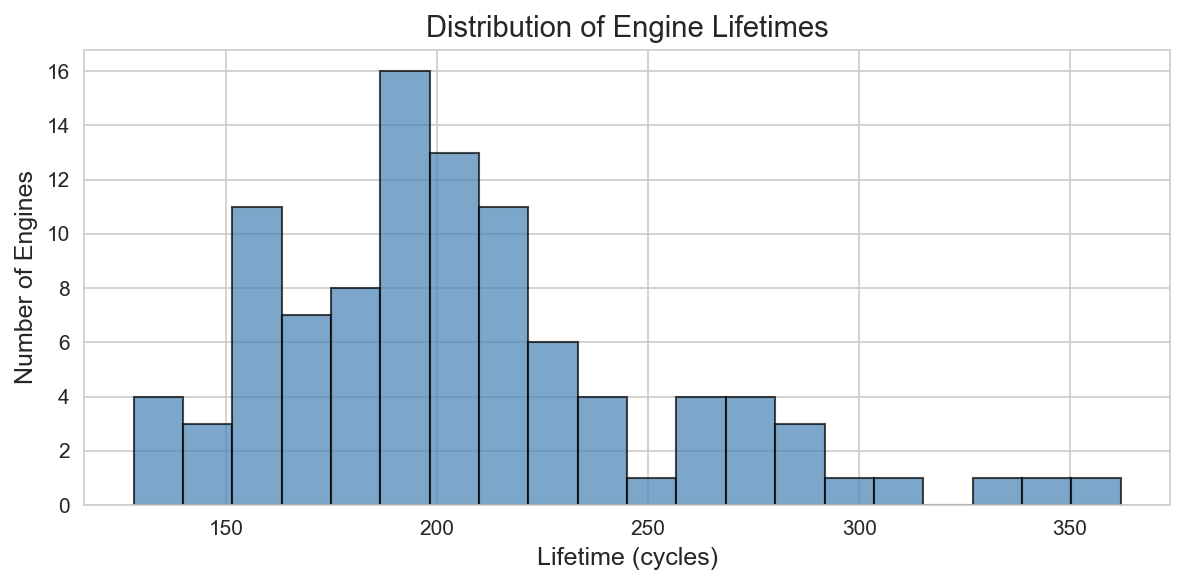

Saved fig_lifetime_dist.png


In [4]:
lifecycle = train_df.groupby('unit')['cycle'].max().reset_index()
lifecycle.columns = ['unit', 'max_cycle']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lifecycle['max_cycle'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Lifetime (cycles)', fontsize=12)
ax.set_ylabel('Number of Engines', fontsize=12)
ax.set_title('Distribution of Engine Lifetimes', fontsize=14)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig_lifetime_dist.png')
plt.show()
print('Saved fig_lifetime_dist.png')

## 4. Figure: Sensor Correlation with RUL

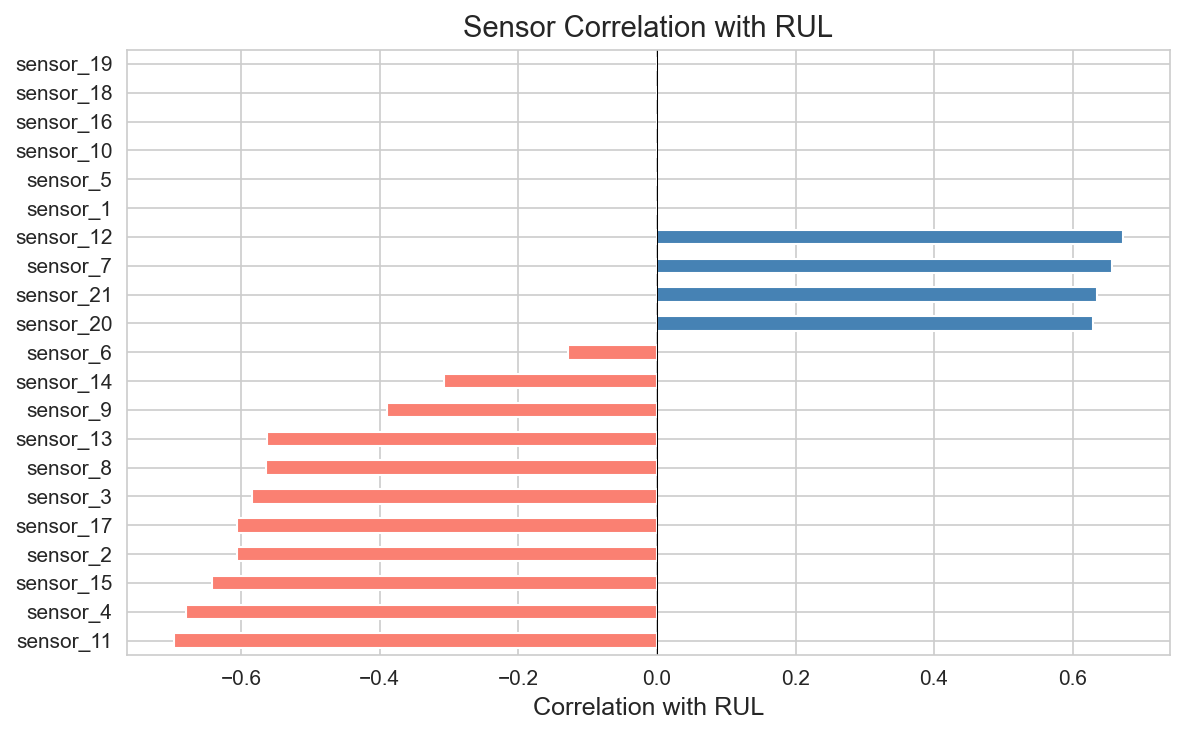

Saved fig_sensor_corr.png


In [5]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
corr_with_rul = train_df[sensor_cols + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_rul.plot(kind='barh', ax=ax,
                   color=['salmon' if v < 0 else 'steelblue' for v in corr_with_rul])
ax.set_xlabel('Correlation with RUL', fontsize=12)
ax.set_title('Sensor Correlation with RUL', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig_sensor_corr.png')
plt.show()
print('Saved fig_sensor_corr.png')

## 5. Figure: Top 6 Sensor Degradation Trends

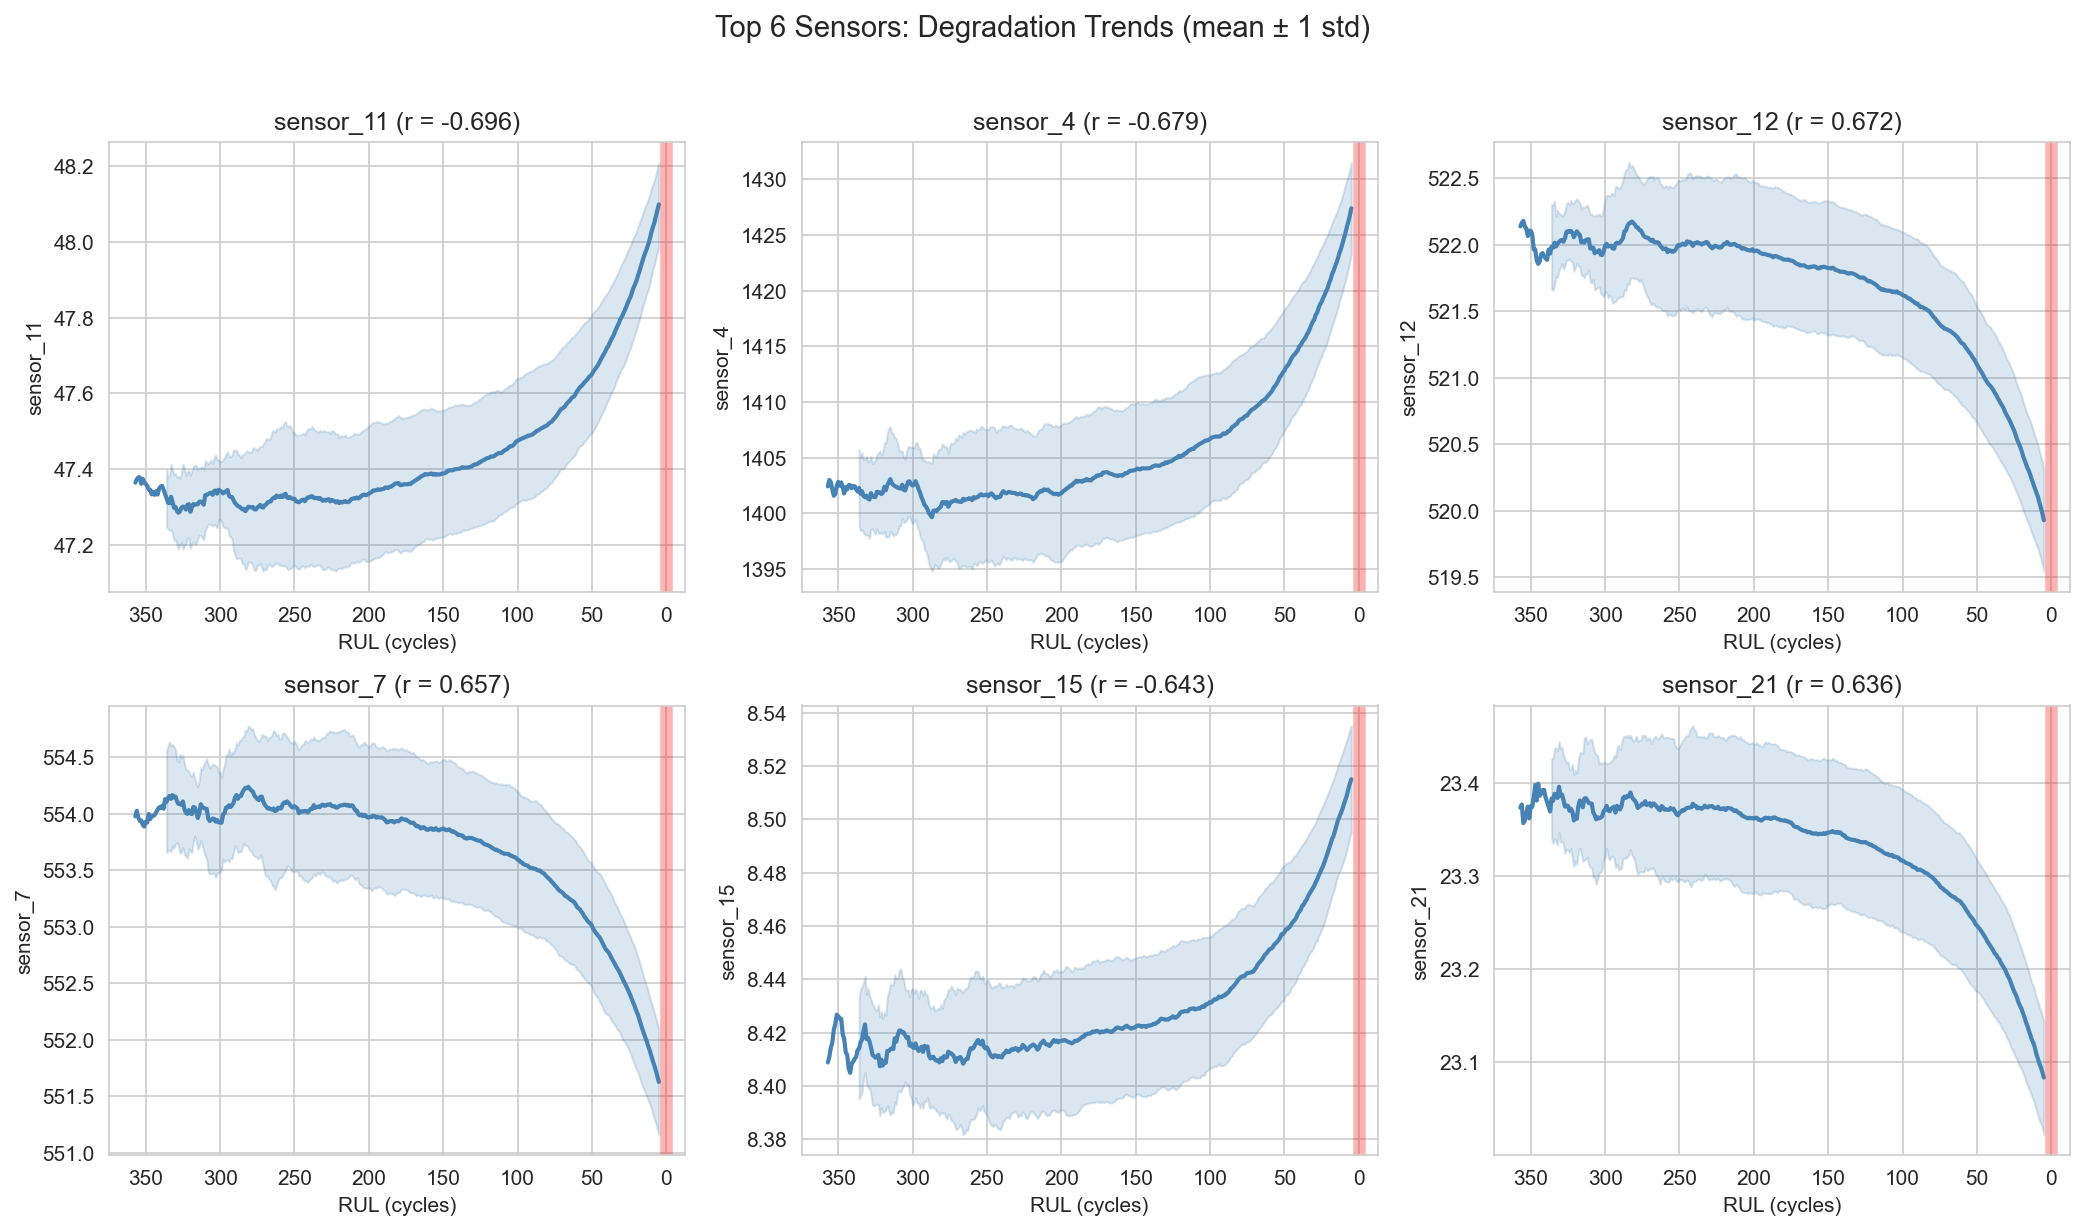

Saved fig_sensor_trends.png


In [6]:
top_sensors = corr_with_rul.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, sensor in enumerate(top_sensors):
    ax = axes[idx]
    grouped = train_df.groupby('RUL')[sensor].agg(['mean', 'std'])
    rul_vals = grouped.index.values
    mean_smooth = grouped['mean'].rolling(window=10, center=True).mean()
    std_smooth = grouped['std'].rolling(window=10, center=True).mean()

    ax.fill_between(rul_vals, mean_smooth - std_smooth, mean_smooth + std_smooth,
                    alpha=0.2, color='steelblue')
    ax.plot(rul_vals, mean_smooth, color='steelblue', linewidth=2)
    ax.set_xlabel('RUL (cycles)')
    ax.set_ylabel(sensor)
    corr_val = corr_with_rul[sensor]
    ax.set_title(f'{sensor} (r = {corr_val:.3f})')
    ax.invert_xaxis()
    ax.axvline(x=0, color='red', linestyle='-', alpha=0.3, linewidth=6)

plt.suptitle('Top 6 Sensors: Degradation Trends (mean \u00b1 1 std)', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig_sensor_trends.png')
plt.show()
print('Saved fig_sensor_trends.png')

## 6. Preprocessing

In [7]:
# Remove constant columns
feature_cols = ['setting_1', 'setting_2', 'setting_3'] + sensor_cols
variances = train_df[feature_cols].var()
constant_cols = variances[variances < 1e-6].index.tolist()
feature_cols = [c for c in feature_cols if c not in constant_cols]
print(f'Removed {len(constant_cols)} constant columns, {len(feature_cols)} features remain')

# Clip RUL at 125
RUL_CLIP = 125
train_df['RUL_clipped'] = train_df['RUL'].clip(upper=RUL_CLIP)

Removed 8 constant columns, 16 features remain


## 7. Figure: Original vs Clipped RUL Distribution

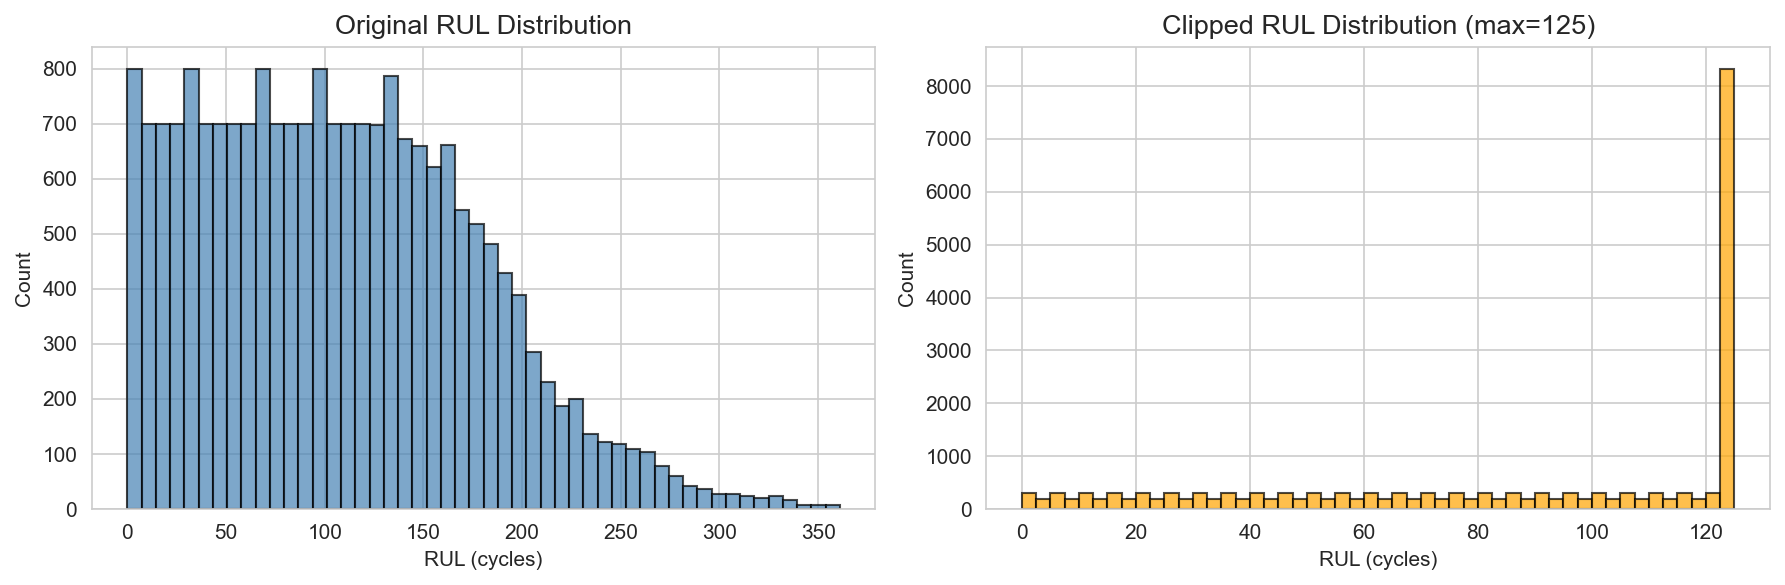

Saved fig_rul_clip.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['RUL'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Original RUL Distribution', fontsize=13)
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Count')

axes[1].hist(train_df['RUL_clipped'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title(f'Clipped RUL Distribution (max={RUL_CLIP})', fontsize=13)
axes[1].set_xlabel('RUL (cycles)')
axes[1].set_ylabel('Count')

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig_rul_clip.png')
plt.show()
print('Saved fig_rul_clip.png')

## 8. Normalize and Train Models

In [9]:
# Normalize features
raw_features = train_df[feature_cols].copy()
scaler = MinMaxScaler()
scaler.fit(raw_features)
train_df[feature_cols] = scaler.transform(raw_features)

# Train/val split
X = train_df[feature_cols].values
y = train_df['RUL_clipped'].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training: {X_train.shape[0]} samples, Validation: {X_val.shape[0]} samples')

# Train all three models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

val_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    val_results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    print(f'{name:20s} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f}')

val_df = pd.DataFrame(val_results)
print('\nValidation Results:')
print(val_df.to_string(index=False))

Training: 16504 samples, Validation: 4127 samples
Linear Regression    | RMSE: 21.68 | MAE: 17.61 | R2: 0.723
Random Forest        | RMSE: 18.77 | MAE: 13.58 | R2: 0.792
XGBoost              | RMSE: 18.72 | MAE: 13.31 | R2: 0.793

Validation Results:
            Model      RMSE       MAE       R2
Linear Regression 21.676610 17.613095 0.723038
    Random Forest 18.773005 13.576683 0.792268
          XGBoost 18.722224 13.313806 0.793390


## 9. Figure: Feature Importance

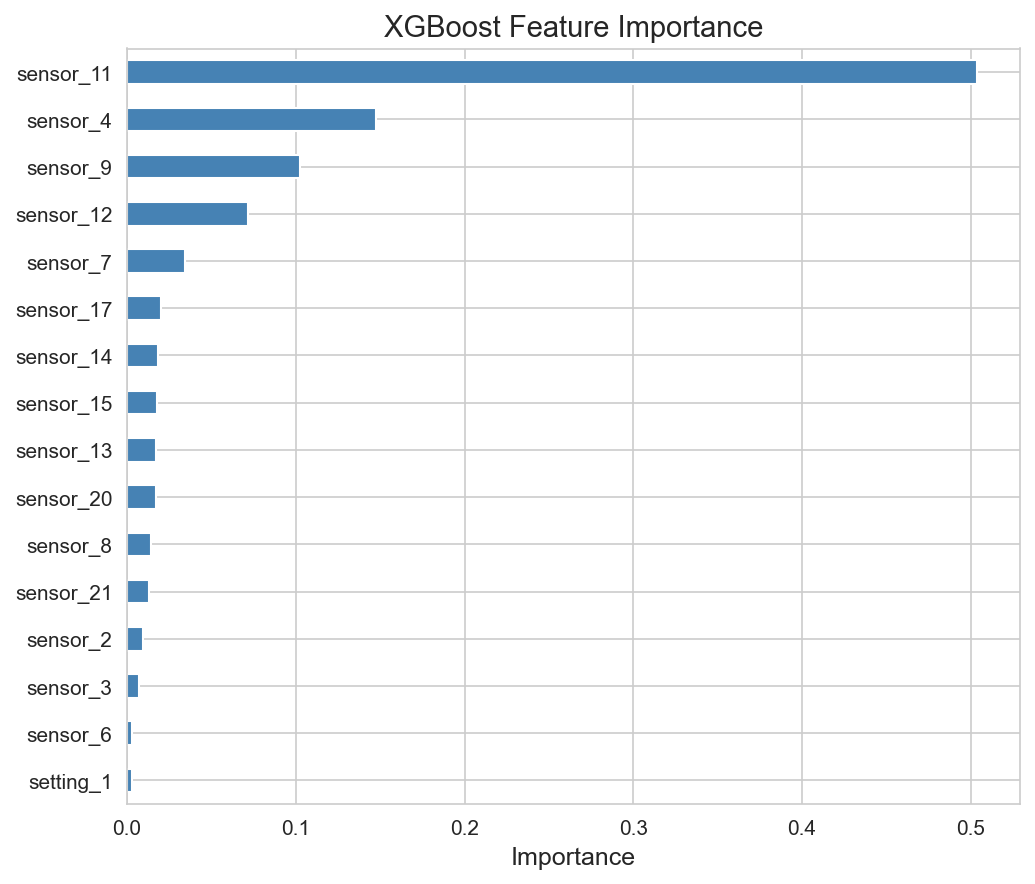

Saved fig_feature_importance.png


In [10]:
best_model = models['XGBoost']
importance = pd.Series(best_model.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
importance.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance', fontsize=14)
ax.set_xlabel('Importance', fontsize=12)
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig_feature_importance.png')
plt.show()
print('Saved fig_feature_importance.png')

## 10. Test Set Evaluation & Scatter Plot

In [11]:
# Load test data
test_df = pd.read_csv('../CMaps/test_FD001.txt',
                       sep='\\s+', header=None, names=columns)
rul_true = pd.read_csv('../CMaps/RUL_FD001.txt',
                        header=None, names=['RUL'])

test_last = test_df.groupby('unit').last().reset_index()
test_last[feature_cols] = scaler.transform(test_last[feature_cols])
y_test_true = rul_true['RUL'].clip(upper=RUL_CLIP).values

X_test = test_last[feature_cols].values
y_test_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
print(f'Test Set Results (XGBoost)')
print(f'RMSE: {test_rmse:.2f} | MAE: {test_mae:.2f} | R2: {test_r2:.3f}')

Test Set Results (XGBoost)
RMSE: 16.73 | MAE: 11.83 | R2: 0.826


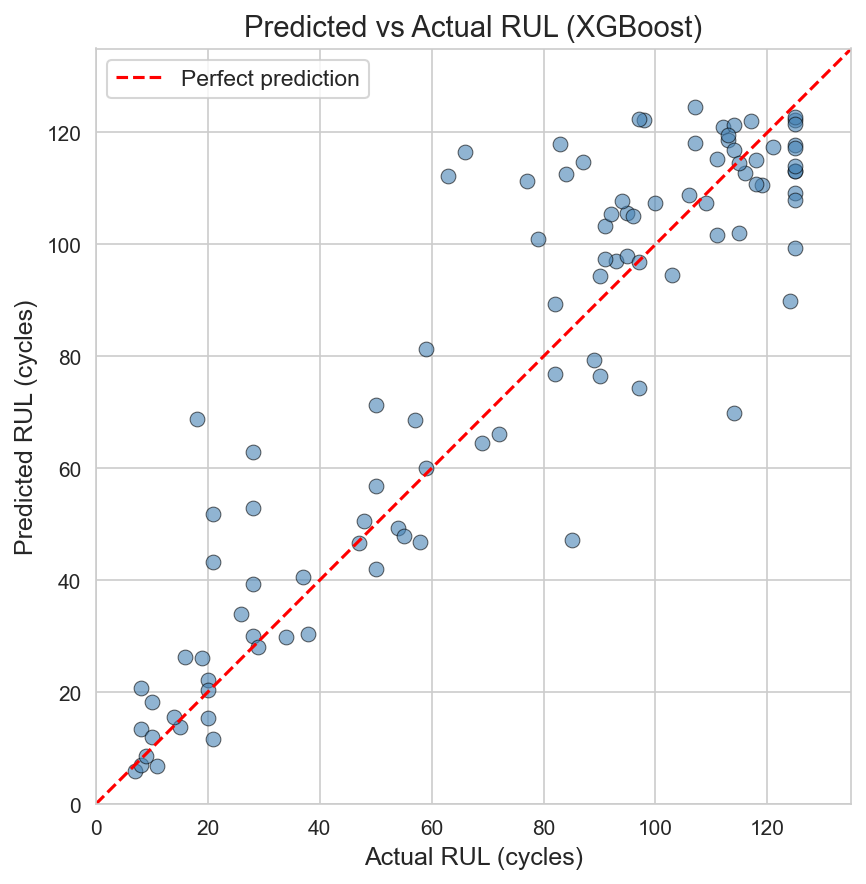

Saved fig_pred_vs_actual.png


In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_true, y_test_pred, alpha=0.6, edgecolors='black',
           linewidths=0.5, color='steelblue', s=50)
max_val = max(y_test_true.max(), y_test_pred.max()) + 10
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual RUL (cycles)', fontsize=12)
ax.set_ylabel('Predicted RUL (cycles)', fontsize=12)
ax.set_title('Predicted vs Actual RUL (XGBoost)', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect('equal')
plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig_pred_vs_actual.png')
plt.show()
print('Saved fig_pred_vs_actual.png')

## Summary

All figures saved to `results/figures/`. Ready for LaTeX report compilation.